# Group B: Scenarios of 100% renewable electricity system in Chile

## Shapes

###### Take the GADM dataset to split the country of your choice into at least 5 regions on which all further modelling will built. 
###### If there are more GADM regions, you may aggregate the regions down to that number.
###### For each region determine a representative point (e.g. centroid). 
###### If your country is not landlocked, also extract the shape of the Exclusive Economic Zone.

In [1]:
from atlite.gis import ExclusionContainer
from atlite.gis import shape_availability
import atlite
import rasterio as rio
from rasterio.plot import show
import geopandas as gpd
import pandas as pd
import numpy as np
import xarray as xr
import os
import matplotlib.pyplot as plt
import country_converter as coco
import pypsa
import rasterio.crs as crs

In [2]:
# Projection to use for all calculations
# ESRI:102033: South_America_Albers_Equal_Area_Conic
c = "ESRI:54017"

### Splitting Chile into regions

In [3]:
new_directory = r'C:\Users\alex-\Desktop\DSEM\Assignment 5\desesm-group-assignment-main'
os.chdir(new_directory)
chile_regions = gpd.read_file("./data/chile_regions.gpkg")
chile_regions.drop(["GID_0", "GID_1", "COUNTRY"],axis=1)
chile_regions

,GID_0,GID_1,COUNTRY,NAME_1,geometry
0,CHL,CHL.2_1,Chile,Antofagasta,"MULTIPOLYGON (((-70.69986 -25.89208, -70.69984..."
1,CHL,CHL.3_1,Chile,Araucanía,"MULTIPOLYGON (((-71.43538 -38.98652, -71.43437..."
2,CHL,CHL.4_1,Chile,Arica y Parinacota,"MULTIPOLYGON (((-69.28189 -17.96854, -69.28175..."
3,CHL,CHL.5_1,Chile,Atacama,"MULTIPOLYGON (((-71.26113 -28.49285, -71.26112..."
4,CHL,CHL.1_1,Chile,Aysén del General Ibañez del Cam,"MULTIPOLYGON (((-75.57556 -48.75867, -75.57551..."
5,CHL,CHL.6_1,Chile,Bío-Bío,"MULTIPOLYGON (((-73.94790 -38.31745, -73.94726..."
6,CHL,CHL.7_1,Chile,Coquimbo,"MULTIPOLYGON (((-70.54495 -31.31045, -70.54525..."
7,CHL,CHL.8_1,Chile,Libertador General Bernardo O'Hi,"MULTIPOLYGON (((-71.54829 -34.87441, -71.54867..."
8,CHL,CHL.9_1,Chile,Los Lagos,"MULTIPOLYGON (((-74.73979 -43.51976, -74.73973..."
9,CHL,CHL.10_1,Chile,Los Ríos,"MULTIPOLYGON (((-71.88819 -40.55778, -71.88676..."


### Aggregate land regions and add EEZ regions

In [4]:
'''def get_centroids(geodataframe, projected_crs='EPSG:4326'):
    """compute centroids for each region in a GeoDataFrame
    INPUT:  geodataframe        - GeoDataFrame of regions
            
    OUTPUT: gpd.GeoDataFrame    - GeoDataFrame with centroids
    """
    # set the coordinate reference system
    geodataframe = geodataframe.to_crs(projected_crs)
    centroids = geodataframe.dissolve(by="NAME_1").centroid
    return gpd.GeoDataFrame(centroids, columns=["geometry"])'''

'def get_centroids(geodataframe, projected_crs=\'EPSG:4326\'):\n    """compute centroids for each region in a GeoDataFrame\n    INPUT:  geodataframe        - GeoDataFrame of regions\n            \n    OUTPUT: gpd.GeoDataFrame    - GeoDataFrame with centroids\n    """\n    # set the coordinate reference system\n    geodataframe = geodataframe.to_crs(projected_crs)\n    centroids = geodataframe.dissolve(by="NAME_1").centroid\n    return gpd.GeoDataFrame(centroids, columns=["geometry"])'

In [5]:
'''chile_centroids = get_centroids(chile_regions, c).to_crs('EPSG:4326')
chile_centroids'''

"chile_centroids = get_centroids(chile_regions, c).to_crs('EPSG:4326')\nchile_centroids"

In [6]:
from sklearn.cluster import AgglomerativeClustering

In [7]:
def aggregate_regions(geodataframe, num_regions):
    # use clustering algorithms K-means to create clusters
    ## extract coordinates for KMeans clustering
    coords = np.array(list(geodataframe.geometry.centroid.apply(lambda point: [point.x, point.y])))
    ## create clusters of regions
    # Create clusters of regions using Agglomerative Clustering
    agglomerative = AgglomerativeClustering(n_clusters=num_regions)
    geodataframe["cluster"] = agglomerative.fit_predict(coords)

    # aggregate regions by clusters
    geodataframe = geodataframe.dissolve(by="cluster")
    geodataframe.NAME_1 = ["CHL1", "CHL2", "CHL3", "CHL4", "CHL5"]
    geodataframe = geodataframe.loc[:, ["NAME_1", "geometry"]].set_index('NAME_1')
    
    return geodataframe

In [8]:
aggregated_regions = aggregate_regions(chile_regions.to_crs(c), 5)

C:\Users\alex-\AppData\Local\Temp\ipykernel_62292\3404950221.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coords = np.array(list(geodataframe.geometry.centroid.apply(lambda point: [point.x, point.y])))


In [9]:
def get_country_economic_zone(EEZ, country):
    """extract the Exclusive Economic Zone (EEZ) for a chosen country
    INPUT:  EEZ                 - GeoDataFrame of EEZ
            country             - Name of the country in string
    OUTPUT: gpd.GeoDataFrame    - GeoDataFrame of the country's EEZ
    """
    return EEZ.query(f"SOVEREIGN1 == '{country}'")

In [10]:
# load Exclusive economic zones
EEZ_boundaries = gpd.read_file("./data/EEZ_boundaries.gpkg")
EEZ = gpd.read_file("./data/EEZ.gpkg")

In [11]:
# Exclusive economic zone of Chile
## extract Chile's EEZ
chile_EEZ = get_country_economic_zone(EEZ, "Chile").to_crs(c)
chile_EEZ = chile_EEZ.rename(columns = {"GEONAME":"NAME_1"}).loc[:, ["NAME_1", "geometry"]].set_index("NAME_1")

In [12]:
chile_regions = pd.concat([chile_regions.to_crs(c), chile_EEZ.to_crs(c)])
# drop 2 islands of EEZ


# update the last row for 1 Chile EEZ
chile_regions.loc[chile_regions.index[-1], 'NAME_1'] = "Chilean Exclusive Economic Zone"
chile_regions.drop(chile_regions[chile_regions["NAME_1"] == "Chilean Exclusive Economic Zone"].index, inplace=True)

In [13]:
## combine Chile aggregated regions and EEZ
aggregated_regions = pd.concat([aggregated_regions, chile_EEZ])

In [14]:
chile_regions1 = pd.concat([chile_regions.to_crs(c), chile_EEZ.to_crs(c)])
# drop 2 islands of EEZ
chile_regions1.drop(chile_regions1.tail(2).index,inplace=True) 
chile_regions1 = chile_regions1.reset_index()

# update the last row for 1 Chile EEZ
chile_regions1.loc[chile_regions1.index[-1], 'index'] = 16
chile_regions1.loc[chile_regions1.index[-1], 'GID_0'] = "CHL"
chile_regions1.loc[chile_regions1.index[-1], 'GID_1'] = "CHL.17_1"
chile_regions1.loc[chile_regions1.index[-1], 'COUNTRY'] = "Chile"
chile_regions1.loc[chile_regions1.index[-1], 'NAME_1'] = "Chilean Exclusive Economic Zone"
chile_regions1.drop(chile_regions1[chile_regions1["NAME_1"] == "Chilean Exclusive Economic Zone"].index, inplace=True)

#### # Create converter DF: 

In [15]:
# Create converter DF: w
regions_converter = gpd.sjoin(chile_regions1,aggregated_regions,how="right",op="within")

c:\Users\alex-\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3493: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [16]:
regions_converter = regions_converter.drop(["index_left", "GID_0", "GID_1", "COUNTRY"],axis=1)
regions_converter.rename(columns={'NAME_1': 'Regions'}, inplace=True)
regions_converter.reset_index(inplace=True)
regions_converter.rename(columns={'NAME_1': 'aggRegions'}, inplace=True)

### Renewables

In [110]:
from atlite.gis import ExclusionContainer
from atlite.gis import shape_availability

In [111]:
country_shapes = "./data/country_shapes.geojson"
roads = "./data/roads.gpkg"
airports = "./data/airports.gpkg"
natural_protection_areas = "./data/natural_protection_areas.tif"
elevation = "./data/elevation.nc"
land_cover = "./data/land_cover.tif"

In [112]:
# Shape of Chile
CHL = gpd.read_file(country_shapes).set_index('name').query("name == 'CL'").to_crs(c).geometry

# Shapes for onshore, offshore and solar
shape_onshore = CHL.geometry 

shape_solar = CHL.geometry

shape_offshore = chile_EEZ.geometry # within EEZ


In [113]:
aggregated_regions

,geometry
NAME_1,
CHL1,"MULTIPOLYGON (((-75.61368 -49.85324, -75.61456..."
CHL2,"MULTIPOLYGON (((-70.69997 -25.89342, -70.70020..."
CHL3,"MULTIPOLYGON (((-109.45240 -27.20056, -109.452..."
CHL4,"MULTIPOLYGON (((-71.53570 -32.16451, -71.53576..."
CHL5,"MULTIPOLYGON (((-74.73901 -43.52268, -74.73918..."
Chilean Exclusive Economic Zone,"MULTIPOLYGON (((-70.93199 -54.75580, -70.92427..."
Chilean Exclusive Economic Zone (San Felix and San Ambrosio islands),"MULTIPOLYGON (((-76.15513 -26.28253, -76.15475..."
Chilean Exclusive Economic Zone (Easter Island),"MULTIPOLYGON (((-105.20748 -23.12633, -105.205..."


In [114]:
shape_CL1 = aggregated_regions.query("NAME_1 == 'CL1'").to_crs(4326).geometry
shape_CL2 = aggregated_regions.query("NAME_1 == 'CL2'").to_crs(4326).geometry
shape_CL3 = aggregated_regions.query("NAME_1 == 'CL3'").to_crs(4326).geometry
shape_CL4 = aggregated_regions.query("NAME_1 == 'CL4'").to_crs(4326).geometry
shape_CL5 = aggregated_regions.query("NAME_1 == 'CL5'").to_crs(4326).geometry

#### Land Eligibility Analysis:

In [115]:
def plot_area(masked, transform, shape, x, y, subplots=0):
    fig, ax = plt.subplots(figsize=(x,y))
    ax = show(masked, transform=transform, cmap='Greens', vmin=0, ax=ax)
    shape.plot(ax=ax, edgecolor='k', color='None', linewidth=1)

In [116]:
def area(masked, excluder, shape):
    excluder_float = float(excluder.res**2)
    return masked.sum() * excluder_float / shape.geometry.area * 100

### Onshore:

In [117]:
excluder_onshore = ExclusionContainer(crs=c)
# 300m distance to major roads
excluder_onshore.add_geometry(roads, buffer=300)
# 10km distance to airports
excluder_onshore.add_geometry(airports, buffer=10000)
# No natural protection areas
excluder_onshore.add_raster(natural_protection_areas, crs=4326)
# Maximum elevation of 2000m
excluder_onshore.add_raster(elevation, codes=lambda x: x>2000, crs=4326)

# 1000m distance to built up areas (i.e. urban land cover class code 50)
excluder_onshore.add_raster(land_cover, codes=[50], buffer=1000, crs=4326)

# Analysis on suitable land cover classes (based on Copernicus document)
## The land cover classes suitable for onshore wind would generally exclude 
## urban, forested (closed forest), agricultural areas with dense canopy, and wetlands, 
## favoring open, non-protected areas.
## Therefore, exclude these code classes 111, 113, 112, 114, 115, 116, 20, 90, 50, 70, 80, 200
excluder_onshore.add_raster(land_cover, codes=[111, 113, 112, 114, 115, 116, 20, 90, 50, 70, 80, 200], buffer=100, crs=32719) 


In [118]:
# calculate available area for onshore wind in single regions
masked_onshore_regions = []
transform_onshore_regions = []
for i in range(0, 5):
    masked_onshore, transform_onshore = shape_availability(gpd.GeoSeries(aggregated_regions.iloc[i], crs=c), excluder_onshore)
    masked_onshore_regions.append(masked_onshore)
    transform_onshore_regions.append(transform_onshore)

C:\Users\alex-\AppData\Roaming\Python\Python310\site-packages\atlite\gis.py:508: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geometry = geometry.buffer(d["buffer"])
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: 

In [123]:
masked_onshore_regions

[array([[False]]),
 array([[False]]),
 array([[False, False]]),
 array([[False]]),
 array([[False]])]

### Offshore:

In [27]:
chile_EEZ

,geometry
NAME_1,
Chilean Exclusive Economic Zone,"MULTIPOLYGON (((-70.93199 -54.75580, -70.92427..."
Chilean Exclusive Economic Zone (San Felix and San Ambrosio islands),"MULTIPOLYGON (((-76.15513 -26.28253, -76.15475..."
Chilean Exclusive Economic Zone (Easter Island),"MULTIPOLYGON (((-105.20748 -23.12633, -105.205..."


In [28]:
### Offshore:
excluder_offshore = ExclusionContainer(crs=c)

# No natural protection areas
excluder_offshore.add_raster(natural_protection_areas, crs=4326)

# 10 km minimum distance to shore
excluder_offshore.add_geometry(CHL, buffer=10000)

# Up to water depth of 50m
excluder_offshore.add_raster(elevation, codes=lambda x: x<-50, crs=4326)

In [33]:
'''masked_offshore, transform_offshore = shape_availability(chile_EEZ, excluder_offshore)

fig, ax = plt.subplots(figsize=(5,5))
ax = show(masked_offshore, transform=transform_offshore, cmap = 'Blues', vmin=0, ax=ax)
shape_offshore.plot(ax=ax, edgecolor='k', color='None', linewidth=0.3)'''


"masked_offshore, transform_offshore = shape_availability(chile_EEZ, excluder_offshore)\n\nfig, ax = plt.subplots(figsize=(5,5))\nax = show(masked_offshore, transform=transform_offshore, cmap = 'Blues', vmin=0, ax=ax)\nshape_offshore.plot(ax=ax, edgecolor='k', color='None', linewidth=0.3)"

In [109]:
# OFFSHORE WIND
masked_offshore_regions = []
transform_offshore_regions = []
for i in chile_EEZ.index:
    masked_onshore, transform_onshore = shape_availability(gpd.GeoSeries(chile_EEZ.loc[i], crs=c), excluder_offshore)
    masked_offshore_regions.append(masked_onshore)
    transform_offshore_regions.append(transform_onshore)

SyntaxError: invalid syntax (3383533941.py, line 1)

### Solar:

In [34]:
excluder_solar = None
excluder_solar = ExclusionContainer(crs=4326)

# Natural protection areas
excluder_solar.add_raster(natural_protection_areas, crs=4326)

# Analysis on suitable land cover classes
## The land cover classes suitable for solar (rooftop and utility) would generally exclude 
## forested, agricultural areas with dense canopy, and wetlands, 
## favoring open, non-protected areas.
## Therefore, exclude these code classes 111, 113, 112, 114, 115, 116, 121, 123, 122, 124, 125, 126, 20, 90, 70, 80, 200

excluder_solar.add_raster(land_cover, codes=[111, 113, 112, 114, 115, 116, 121, 123, 122, 124, 125, 126, 20, 90, 70, 80, 200], buffer=100, crs=4326)

In [ ]:
# calculate available area for onshore wind in single regions
masked_solar_regions = []
transform_solar_regions = []
for i in range(0, 5):
    masked_solar, transform_solar = shape_availability(gpd.GeoSeries(aggregated_regions.iloc[i], crs=c), excluder_solar)
    masked_solar_regions.append(masked_onshore)
    transform_solar_regions.append(transform_onshore)

### Weather Data

In [ ]:
minx, miny, maxx, maxy = chile_regions.total_bounds
buffer = 0.25

In [ ]:
import atlite
cutout = atlite.Cutout("./data/cutout-2013-era5.nc")

### Onshore wind - Vestast V112 3MW

In [ ]:
aggregated_regions.geometry = gpd.GeoSeries(aggregated_regions["geometry"], crs=c)

In [ ]:
aggregated_regions[0:5].index

Index(['CHL1', 'CHL2', 'CHL3', 'CHL4', 'CHL5'], dtype='object', name='NAME_1')

In [ ]:
A = cutout.availabilitymatrix(aggregated_regions[0:5].geometry, excluder_onshore)

Compute availability matrix: 100%|██████████| 5/5 [05:26<00:00, 65.27s/ gridcells]


In [ ]:
# For both wind and solar, assume a deployment density of 3 MW/km2
cap_per_sqkm = 3 # MW/km2
area = cutout.grid.set_index(['y', 'x']).to_crs(4326).area / 1e6
area = xr.DataArray(area, dims=('spatial'))
onshore_capacity_matrix = A.stack(spatial=["y", "x"]) * area * cap_per_sqkm

C:\Users\alex-\AppData\Local\Temp\ipykernel_39000\3641957331.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  area = cutout.grid.set_index(['y', 'x']).to_crs(4326).area / 1e6


In [ ]:
wind = cutout.wind(
    atlite.windturbines.Vestas_V112_3MW,
    matrix=onshore_capacity_matrix,
    index=aggregated_regions[0:5].index,
    per_unit=True,
)

C:\Users\alex-\AppData\Roaming\Python\Python310\site-packages\atlite\resource.py:72: FutureWarning: 'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.13.
  warnings.warn(msg, FutureWarning)


[########################################] | 100% Completed | 215.74 s


In [ ]:
wind = wind.to_pandas()
wind.to_csv("./data/A_Wind", index=False)

### Solar panel - CdTe

In [ ]:
solar_regions = chile_regions[0:15]

In [ ]:
A_solar = cutout.availabilitymatrix(unshore_regions, excluder_solar)

Compute availability matrix:   0%|          | 0/15 [00:00<?, ? gridcells/s]

Compute availability matrix: 100%|██████████| 15/15 [00:25<00:00,  1.68s/ gridcells]


In [ ]:
solar_regions.index

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], dtype='object')

In [ ]:
capacity_matrix_solar = A_solar.stack(spatial=['y', 'x']) * area * cap_per_sqkm

In [35]:
'''pv = cutout.pv(
    panel=atlite.solarpanels.CdTe,
    matrix=capacity_matrix_solar,
    orientation='latitude_optimal',
    index=solar_regions.index,
    per_unit=True,
)'''

"pv = cutout.pv(\n    panel=atlite.solarpanels.CdTe,\n    matrix=capacity_matrix_solar,\n    orientation='latitude_optimal',\n    index=solar_regions.index,\n    per_unit=True,\n)"

In [ ]:
# capacity factor time series of solar
df_pv = pv.to_pandas()

NAME_1,CHL1,CHL2,CHL3,CHL4,CHL5
time,,,,,
2013-01-01 00:00:00,0.060006,0.000019,0.018331,0.006247,0.029967
2013-01-01 01:00:00,0.016625,0.000000,0.000135,0.000000,0.000011
2013-01-01 02:00:00,0.000000,0.000000,0.000022,0.000000,0.000000
2013-01-01 03:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
2013-01-01 04:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...
2013-12-31 19:00:00,0.451974,0.762323,0.809928,0.839488,0.365366
2013-12-31 20:00:00,0.445929,0.626014,0.702470,0.731086,0.341919
2013-12-31 21:00:00,0.383134,0.474408,0.555481,0.558563,0.310579


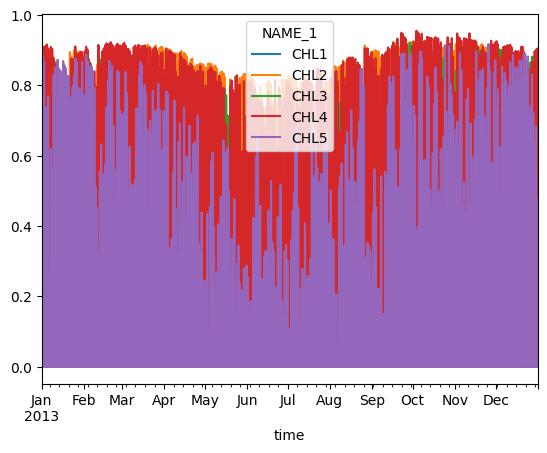

In [ ]:
df_pv.plot()
df_pv.to_csv("./data/A_Solar", index=False)

### Offshore wind - NREL ReferenceTurbine 5MW offshore

In [ ]:
aggregated_regions.iloc[5:8]

,geometry
NAME_1,
Chilean Exclusive Economic Zone,"MULTIPOLYGON (((-808425.879 -2504985.792, -807..."
Chilean Exclusive Economic Zone (San Felix and San Ambrosio islands),"MULTIPOLYGON (((-1528105.804 584286.120, -1527..."
Chilean Exclusive Economic Zone (Easter Island),"MULTIPOLYGON (((-4329434.259 383144.671, -4329..."


In [ ]:
### Offshore wind - NREL ReferenceTurbine 5MW offshore
offhore_region = aggregated_regions.iloc[5:8]
offhore_region

,geometry
NAME_1,
Chilean Exclusive Economic Zone,"MULTIPOLYGON (((-808425.879 -2504985.792, -807..."
Chilean Exclusive Economic Zone (San Felix and San Ambrosio islands),"MULTIPOLYGON (((-1528105.804 584286.120, -1527..."
Chilean Exclusive Economic Zone (Easter Island),"MULTIPOLYGON (((-4329434.259 383144.671, -4329..."


In [36]:
'''A_offshore = cutout.availabilitymatrix(offhore_region, excluder_offshore)'''

'A_offshore = cutout.availabilitymatrix(offhore_region, excluder_offshore)'

In [ ]:
# For both wind and solar, assume a deployment density of 3 MW/km2
cap_per_sqkm = 3 # MW/km2
area = cutout.grid.set_index(['y', 'x']).to_crs(4326).area / 1e6
area = xr.DataArray(area, dims=('spatial'))
offshore_capacity_matrix = A_offshore.stack(spatial=["y", "x"]) * area * cap_per_sqkm

C:\Users\alex-\AppData\Local\Temp\ipykernel_39000\816470729.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  area = cutout.grid.set_index(['y', 'x']).to_crs(4326).area / 1e6


In [ ]:
windoffshore = cutout.wind(
    atlite.windturbines.NREL_ReferenceTurbine_5MW_offshore,
    matrix=offshore_capacity_matrix,
    index=offhore_region.index,
    per_unit=True,
)

C:\Users\alex-\AppData\Roaming\Python\Python310\site-packages\atlite\resource.py:72: FutureWarning: 'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.13.
  warnings.warn(msg, FutureWarning)


[########################################] | 100% Completed | 214.59 s


In [ ]:
# capacity factor time series of solar
df_offshore = windoffshore.to_pandas()

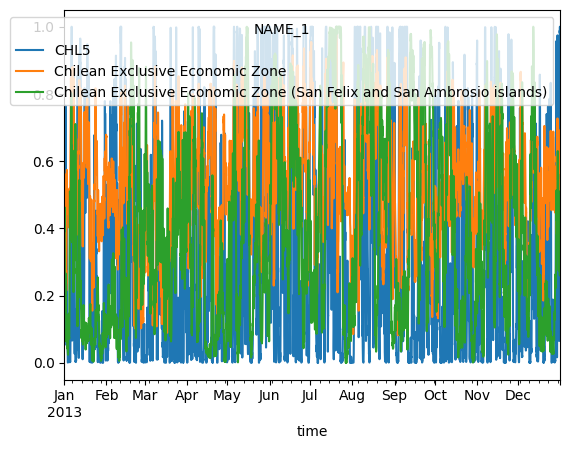

In [ ]:
df_offshore.plot()
df_offshore.to_csv("./data/A_Offshore", index=False)

## Adding Generators

#### Add Costs

In [17]:
# technology
year = 2050
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])
costs

value  \
technology                        parameter                      
Ammonia cracker                   FOM                   4.3000   
                                  ammonia-input         1.4600   
                                  investment       527592.2200   
                                  lifetime             25.0000   
Battery electric (passenger cars) FOM                   0.9000   
...                                                        ...   
waste CHP CC                      efficiency-heat       0.7625   
                                  investment         7068.8867   
                                  lifetime             25.0000   
water tank charger                efficiency            0.8367   
water tank discharger             efficiency            0.8367   

                                                             unit  \
technology                        parameter                         
Ammonia cracker                   FOM                      %/year   
                                  ammonia-input    MWh_NH3/MWh_H2   
                                  investment            EUR/MW_H2   
                                  lifetime                  years   
Battery electric (passenger cars) FOM                           %   
...                                                           ...   
waste CHP CC                      efficiency-heat        per unit   
                                  investment             EUR/kW_e   
                                  lifetime                  years   
water tank charger                efficiency             per unit   
water tank discharger             efficiency             per unit   

                                                                                              source  \
technology                        parameter                                                            
Ammonia cracker                   FOM              Ishimoto et al. (2020): 10.1016/j.ijhydene.202...   
                                  ammonia-input    ENGIE et al (2020): Ammonia to Green Hydrogen ...   
                                  investment       Ishimoto et al. (2020): 10.1016/j.ijhydene.202...   
                                  lifetime         Ishimoto et al. (2020): 10.1016/j.ijhydene.202...   
Battery electric (passenger cars) FOM              PATHS TO A CLIMATE-NEUTRAL ENERGY SYSTEM The G...   
...                                                                                              ...   
waste CHP CC                      efficiency-heat  Danish Energy Agency, technology_data_for_el_a...   
                                  investment       Danish Energy Agency, technology_data_for_el_a...   
                                  lifetime         Danish Energy Agency, technology_data_for_el_a...   
water tank charger                efficiency       Danish Energy Agency, technology_data_catalogu...   
water tank discharger             efficiency       Danish Energy Agency, technology_data_catalogu...   

                                                                                 further description  
technology                        parameter                                                           
Ammonia cracker                   FOM              Estimated based on Labour cost rate, Maintenan...  
                                  ammonia-input    Assuming a integrated 200t/d cracking and puri...  
                                  investment       Calculated. For a small (200 t_NH3/d input) fa...  
                                  lifetime                                                       NaN  
Battery electric (passenger cars) FOM                              Battery electric (passenger cars)  
...                                                                                              ...  
waste CHP CC                      efficiency-heat  08 WtE CHP, Large, 50 degree:  Heat efficiency...  
                    

In [18]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

In [19]:
# Question: Why Petcoke = Gas? Rather Oil
costs.at["petcoke", "fuel"] = costs.at["oil", "fuel"]
costs.at["petcoke", "fuel"] = costs.at["oil", "fuel"]
costs.at["petcoke", "CO2 intensity"] = costs.at["oil", "CO2 intensity"]
costs.at["petcoke", "CO2 intensity"] = costs.at["oil", "CO2 intensity"]

In [20]:
# Annuity
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

In [21]:
# Marginal cost,  €/MWh
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"] 

In [22]:
# Capital cost, €/MW/a
annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)
costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

In [23]:
costs[costs.index=="solar"]

parameter,C in fuel,C stored,CO2 intensity,CO2 stored,FOM,VOM,ammonia-input,c_b,c_v,capacity,...,methane-input,methanol-input,min_fill_level,naphtha-input,nitrogen-input,ore-input,p_nom_ratio,pelletizing cost,marginal_cost,capital_cost
technology,,,,,,,,,,,,,,,,,,,,,
solar,NaN,NaN,NaN,NaN,2.0676,0.01,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.01,35421.490189


### Add Power  Plants

In [24]:
# Add the fleet of existing power plants
pwp = pd.read_csv(".\data\global_power_plant_database.csv", index_col=0, parse_dates=True)

C:\Users\alex-\AppData\Local\Temp\ipykernel_62292\2726276955.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  pwp = pd.read_csv(".\data\global_power_plant_database.csv", index_col=0, parse_dates=True)
C:\Users\alex-\AppData\Local\Temp\ipykernel_62292\2726276955.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pwp = pd.read_csv(".\data\global_power_plant_database.csv", index_col=0, parse_dates=True)


In [25]:
# Power plants in Chile
geometry = gpd.points_from_xy(pwp["longitude"], pwp["latitude"])
pwp_gdf = gpd.GeoDataFrame(pwp, geometry=geometry, crs=c)
pwp_chile = pwp_gdf.query("country_long =='Chile'")
pwp_chile = pwp_chile.set_geometry('geometry')


In [26]:
# Disregard existing wind and solar capacities
pwp_chile = pwp_chile[~pwp_chile['primary_fuel'].isin(['Wind', 'Solar'])]

In [27]:
aggregated_regions = gpd.GeoDataFrame(aggregated_regions,geometry="geometry")

In [28]:
regions_converter = regions_converter.to_crs(c)
pwp_chile = pwp_chile .to_crs(c)

### Aggregate fossil power plants over different plants of the same type

In [29]:
### Joining Powerplant, Cost and Geographic DataFrames
# 14 regions
pwp_chile = gpd.sjoin(pwp_chile,chile_regions, how='left', op='within')

c:\Users\alex-\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3493: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [30]:
pwp_chile.head()

,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,other_fuel3,...,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017,geometry,index_right,GID_0,GID_1,COUNTRY,NAME_1
country,,,,,,,,,,,,,,,,,,,,,
CHL,Chile,ABANICO,CHL0001001,136.0,-37.3646,-71.4894,Hydro,NaN,NaN,NaN,...,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,POINT (-71.48940 -37.36460),5,CHL,CHL.6_1,Chile,Bío-Bío
CHL,Chile,AGUAS BLANCAS,CHL0000001,2.0,-24.1355,-69.8649,Oil,NaN,NaN,NaN,...,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (-69.86490 -24.13550),0,CHL,CHL.2_1,Chile,Antofagasta
CHL,Chile,ALFALFAL,CHL0001002,178.0,-33.5012,-70.1927,Hydro,NaN,NaN,NaN,...,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,POINT (-70.19270 -33.50120),13,CHL,CHL.14_1,Chile,Santiago Metropolitan
CHL,Chile,ALLIPEN,CHL0001003,3.0,-38.9987,-72.2230,Hydro,NaN,NaN,NaN,...,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,POINT (-72.22300 -38.99870),1,CHL,CHL.3_1,Chile,Araucanía
CHL,Chile,ANGOL (LOS SAUCES),CHL0000134,1.5,-37.9658,-72.8269,Oil,NaN,NaN,NaN,...,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (-72.82690 -37.96580),1,CHL,CHL.3_1,Chile,Araucanía


In [31]:
pwp_chile["p_max_pu"] = pwp_chile.estimated_generation_gwh_2017*(1e3)/8760/pwp_chile.capacity_mw
pwp_chile.head()

,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,other_fuel3,...,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017,geometry,index_right,GID_0,GID_1,COUNTRY,NAME_1,p_max_pu
country,,,,,,,,,,,,,,,,,,,,,
CHL,Chile,ABANICO,CHL0001001,136.0,-37.3646,-71.4894,Hydro,NaN,NaN,NaN,...,HYDRO-V1,HYDRO-V1,HYDRO-V1,POINT (-71.48940 -37.36460),5,CHL,CHL.6_1,Chile,Bío-Bío,0.333266
CHL,Chile,AGUAS BLANCAS,CHL0000001,2.0,-24.1355,-69.8649,Oil,NaN,NaN,NaN,...,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (-69.86490 -24.13550),0,CHL,CHL.2_1,Chile,Antofagasta,0.066781
CHL,Chile,ALFALFAL,CHL0001002,178.0,-33.5012,-70.1927,Hydro,NaN,NaN,NaN,...,HYDRO-V1,HYDRO-V1,HYDRO-V1,POINT (-70.19270 -33.50120),13,CHL,CHL.14_1,Chile,Santiago Metropolitan,0.340965
CHL,Chile,ALLIPEN,CHL0001003,3.0,-38.9987,-72.2230,Hydro,NaN,NaN,NaN,...,HYDRO-V1,HYDRO-V1,HYDRO-V1,POINT (-72.22300 -38.99870),1,CHL,CHL.3_1,Chile,Araucanía,0.445586
CHL,Chile,ANGOL (LOS SAUCES),CHL0000134,1.5,-37.9658,-72.8269,Oil,NaN,NaN,NaN,...,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (-72.82690 -37.96580),1,CHL,CHL.3_1,Chile,Araucanía,0.066210


In [32]:
pwp_chile["Weighted_Regional_Capacity"] = 0
grouped_sum = pwp_chile.groupby(["NAME_1", "primary_fuel"])["capacity_mw"].transform('sum')
pwp_chile["Weighted_Regional_Capacity"] = (pwp_chile['p_max_pu'] * pwp_chile['capacity_mw']) / grouped_sum
pwp_chile["Weighted_Regional_Capacity"]

country
CHL    0.015864
CHL    0.000966
CHL    0.163150
CHL    0.037132
CHL    0.007197
         ...   
CHL    0.010559
CHL    0.208233
CHL    0.015073
CHL    0.001236
CHL    0.028111
Name: Weighted_Regional_Capacity, Length: 220, dtype: float64

In [33]:
# Aggregate Capacity Factors
aggregated_plants_cf = pwp_chile.groupby(["NAME_1","primary_fuel"])["Weighted_Regional_Capacity"].sum().unstack().fillna(0)
aggregated_plants_capacity = pwp_chile.groupby(["NAME_1","primary_fuel"])["capacity_mw"].sum().unstack().fillna(0)
aggregated_plants_capacity

primary_fuel,Biomass,Coal,Gas,Hydro,Oil,Petcoke
NAME_1,,,,,,
Antofagasta,0.0,747.6000,1012.200000,0.0,138.200000,0.0000
Araucanía,81.0,0.0000,0.000000,36.0,13.800000,0.0000
Arica y Parinacota,0.0,0.0000,0.000000,10.0,14.200000,0.0000
Atacama,0.0,760.0000,0.000000,5.0,511.301450,0.0000
Bío-Bío,168.2,819.9910,61.157689,2857.0,473.049478,62.9775
Coquimbo,0.0,0.0000,0.000000,29.0,354.647000,0.0000
Libertador General Bernardo O'Hi,15.6,0.0000,253.900000,949.0,43.400000,0.0000
Los Lagos,0.0,0.0000,0.000000,288.0,161.600000,0.0000
Los Ríos,0.0,0.0000,0.000000,122.0,117.200000,0.0000


In [34]:
aggregated_plants_cf.reset_index(inplace=True)
aggregated_plants_capacity.reset_index(inplace=True)

In [35]:
# ### Collapse Aggregated_Plants Data to five region level
aggregated_plants_cf = pd.merge(aggregated_plants_cf, chile_regions, on="NAME_1", how="inner")
aggregated_plants_capacity = pd.merge(aggregated_plants_capacity, chile_regions, on="NAME_1", how="inner")
aggregated_plants_capacity

,NAME_1,Biomass,Coal,Gas,Hydro,Oil,Petcoke,GID_0,GID_1,COUNTRY,geometry
0,Antofagasta,0.0,747.6000,1012.200000,0.0,138.200000,0.0000,CHL,CHL.2_1,Chile,"MULTIPOLYGON (((-70.69986 -25.89208, -70.69984..."
1,Araucanía,81.0,0.0000,0.000000,36.0,13.800000,0.0000,CHL,CHL.3_1,Chile,"MULTIPOLYGON (((-71.43538 -38.98652, -71.43437..."
2,Arica y Parinacota,0.0,0.0000,0.000000,10.0,14.200000,0.0000,CHL,CHL.4_1,Chile,"MULTIPOLYGON (((-69.28189 -17.96854, -69.28175..."
3,Atacama,0.0,760.0000,0.000000,5.0,511.301450,0.0000,CHL,CHL.5_1,Chile,"MULTIPOLYGON (((-71.26113 -28.49285, -71.26112..."
4,Bío-Bío,168.2,819.9910,61.157689,2857.0,473.049478,62.9775,CHL,CHL.6_1,Chile,"MULTIPOLYGON (((-73.94790 -38.31745, -73.94726..."
5,Coquimbo,0.0,0.0000,0.000000,29.0,354.647000,0.0000,CHL,CHL.7_1,Chile,"MULTIPOLYGON (((-70.54495 -31.31045, -70.54525..."
6,Libertador General Bernardo O'Hi,15.6,0.0000,253.900000,949.0,43.400000,0.0000,CHL,CHL.8_1,Chile,"MULTIPOLYGON (((-71.54829 -34.87441, -71.54867..."
7,Los Lagos,0.0,0.0000,0.000000,288.0,161.600000,0.0000,CHL,CHL.9_1,Chile,"MULTIPOLYGON (((-74.73979 -43.51976, -74.73973..."
8,Los Ríos,0.0,0.0000,0.000000,122.0,117.200000,0.0000,CHL,CHL.10_1,Chile,"MULTIPOLYGON (((-71.88819 -40.55778, -71.88676..."
9,Maule,14.0,2.0000,0.000000,1592.0,87.414000,0.0000,CHL,CHL.12_1,Chile,"MULTIPOLYGON (((-71.52672 -34.87628, -71.52669..."


In [36]:
aggregated_plants_cf = gpd.GeoDataFrame(aggregated_plants_cf,geometry=aggregated_plants_cf["geometry"],crs=c)
aggregated_plants_capacity = gpd.GeoDataFrame(aggregated_plants_capacity,geometry=aggregated_plants_capacity["geometry"],crs=c)
aggregated_plants_capacity

,NAME_1,Biomass,Coal,Gas,Hydro,Oil,Petcoke,GID_0,GID_1,COUNTRY,geometry
0,Antofagasta,0.0,747.6000,1012.200000,0.0,138.200000,0.0000,CHL,CHL.2_1,Chile,"MULTIPOLYGON (((-70.69986 -25.89208, -70.69984..."
1,Araucanía,81.0,0.0000,0.000000,36.0,13.800000,0.0000,CHL,CHL.3_1,Chile,"MULTIPOLYGON (((-71.43538 -38.98652, -71.43437..."
2,Arica y Parinacota,0.0,0.0000,0.000000,10.0,14.200000,0.0000,CHL,CHL.4_1,Chile,"MULTIPOLYGON (((-69.28189 -17.96854, -69.28175..."
3,Atacama,0.0,760.0000,0.000000,5.0,511.301450,0.0000,CHL,CHL.5_1,Chile,"MULTIPOLYGON (((-71.26113 -28.49285, -71.26112..."
4,Bío-Bío,168.2,819.9910,61.157689,2857.0,473.049478,62.9775,CHL,CHL.6_1,Chile,"MULTIPOLYGON (((-73.94790 -38.31745, -73.94726..."
5,Coquimbo,0.0,0.0000,0.000000,29.0,354.647000,0.0000,CHL,CHL.7_1,Chile,"MULTIPOLYGON (((-70.54495 -31.31045, -70.54525..."
6,Libertador General Bernardo O'Hi,15.6,0.0000,253.900000,949.0,43.400000,0.0000,CHL,CHL.8_1,Chile,"MULTIPOLYGON (((-71.54829 -34.87441, -71.54867..."
7,Los Lagos,0.0,0.0000,0.000000,288.0,161.600000,0.0000,CHL,CHL.9_1,Chile,"MULTIPOLYGON (((-74.73979 -43.51976, -74.73973..."
8,Los Ríos,0.0,0.0000,0.000000,122.0,117.200000,0.0000,CHL,CHL.10_1,Chile,"MULTIPOLYGON (((-71.88819 -40.55778, -71.88676..."
9,Maule,14.0,2.0000,0.000000,1592.0,87.414000,0.0000,CHL,CHL.12_1,Chile,"MULTIPOLYGON (((-71.52672 -34.87628, -71.52669..."


In [37]:
aggregated_plants_cf.drop(columns="GID_0",inplace=True)
aggregated_plants_cf.drop(columns="GID_1",inplace=True)
aggregated_plants_capacity.drop(columns="GID_0",inplace=True)
aggregated_plants_capacity.drop(columns="GID_1",inplace=True)

In [38]:
# Merge Capacity Factor to Aggregated Regions
aggregated_plants_cf = gpd.sjoin(aggregated_plants_cf, aggregated_regions, op='within')

c:\Users\alex-\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3493: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [39]:
aggregated_plants_cf.rename(columns={'index_right': 'aggRegion'}, inplace=True)

In [40]:
# Merge Capacity to 5 Aggregated Regions of Interest
aggregated_plants_capacity = gpd.sjoin(aggregated_plants_capacity, aggregated_regions, op='within')
aggregated_plants_capacity.rename(columns={'index_right': 'aggRegion'}, inplace=True)

c:\Users\alex-\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3493: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [41]:
aggregated_plants_capacity.rename(columns={'index_right': 'aggRegion'}, inplace=True)
aggregated_plants_capacity

,NAME_1,Biomass,Coal,Gas,Hydro,Oil,Petcoke,COUNTRY,geometry,aggRegion
0,Antofagasta,0.0,747.6000,1012.200000,0.0,138.200000,0.0000,Chile,"MULTIPOLYGON (((-70.69986 -25.89208, -70.69984...",CHL2
2,Arica y Parinacota,0.0,0.0000,0.000000,10.0,14.200000,0.0000,Chile,"MULTIPOLYGON (((-69.28189 -17.96854, -69.28175...",CHL2
1,Araucanía,81.0,0.0000,0.000000,36.0,13.800000,0.0000,Chile,"MULTIPOLYGON (((-71.43538 -38.98652, -71.43437...",CHL5
7,Los Lagos,0.0,0.0000,0.000000,288.0,161.600000,0.0000,Chile,"MULTIPOLYGON (((-74.73979 -43.51976, -74.73973...",CHL5
8,Los Ríos,0.0,0.0000,0.000000,122.0,117.200000,0.0000,Chile,"MULTIPOLYGON (((-71.88819 -40.55778, -71.88676...",CHL5
3,Atacama,0.0,760.0000,0.000000,5.0,511.301450,0.0000,Chile,"MULTIPOLYGON (((-71.26113 -28.49285, -71.26112...",CHL4
5,Coquimbo,0.0,0.0000,0.000000,29.0,354.647000,0.0000,Chile,"MULTIPOLYGON (((-70.54495 -31.31045, -70.54525...",CHL4
4,Bío-Bío,168.2,819.9910,61.157689,2857.0,473.049478,62.9775,Chile,"MULTIPOLYGON (((-73.94790 -38.31745, -73.94726...",CHL3
6,Libertador General Bernardo O'Hi,15.6,0.0000,253.900000,949.0,43.400000,0.0000,Chile,"MULTIPOLYGON (((-71.54829 -34.87441, -71.54867...",CHL3
9,Maule,14.0,2.0000,0.000000,1592.0,87.414000,0.0000,Chile,"MULTIPOLYGON (((-71.52672 -34.87628, -71.52669...",CHL3


In [42]:
# Melt Capacity
aggregated_plants_capacity = pd.melt(aggregated_plants_capacity, id_vars=['NAME_1', 'geometry', "aggRegion"],
                    value_vars=['Biomass', 'Coal', 'Gas', 'Hydro', 'Oil', 'Petcoke'],
                    var_name='primary_fuel', value_name='Capacity_MW')

In [43]:
# Melt Capacity Factors
aggregated_plants_cf = pd.melt(aggregated_plants_cf, id_vars=['NAME_1', 'geometry', "aggRegion"],
                    value_vars=['Biomass', 'Coal', 'Gas', 'Hydro', 'Oil', 'Petcoke'],
                    var_name='primary_fuel', value_name='p_max_pu')

In [44]:
aggregated_plants_cf.rename(columns={"NAME_1_right": "NAME_1"}, inplace=True)
aggregated_plants_capacity.rename(columns={"NAME_1_left": "NAME_1"}, inplace=True)

In [45]:
aggregated_plants = aggregated_plants_cf.merge(aggregated_plants_capacity, on=["NAME_1", "geometry", "primary_fuel"])

In [46]:
aggregated_plants["Weighted_Agg_CF"] = 0

In [47]:
grouped_sum = aggregated_plants.groupby(["aggRegion_y", "primary_fuel"])["Capacity_MW"].transform('sum')
aggregated_plants["Weighted_Agg_CF"] = (aggregated_plants['p_max_pu'] * aggregated_plants['Capacity_MW']) / grouped_sum

In [48]:
aggregated_plants[aggregated_plants["primary_fuel"]=="Coal"]

,NAME_1,geometry,aggRegion_x,primary_fuel,p_max_pu,aggRegion_y,Capacity_MW,Weighted_Agg_CF
13,Antofagasta,"MULTIPOLYGON (((-70.69986 -25.89208, -70.69984...",CHL2,Coal,0.629793,CHL2,747.6000,0.629793
14,Arica y Parinacota,"MULTIPOLYGON (((-69.28189 -17.96854, -69.28175...",CHL2,Coal,0.000000,CHL2,0.0000,0.000000
15,Araucanía,"MULTIPOLYGON (((-71.43538 -38.98652, -71.43437...",CHL5,Coal,0.000000,CHL5,0.0000,NaN
16,Los Lagos,"MULTIPOLYGON (((-74.73979 -43.51976, -74.73973...",CHL5,Coal,0.000000,CHL5,0.0000,NaN
17,Los Ríos,"MULTIPOLYGON (((-71.88819 -40.55778, -71.88676...",CHL5,Coal,0.000000,CHL5,0.0000,NaN
18,Atacama,"MULTIPOLYGON (((-71.26113 -28.49285, -71.26112...",CHL4,Coal,0.629793,CHL4,760.0000,0.629793
19,Coquimbo,"MULTIPOLYGON (((-70.54495 -31.31045, -70.54525...",CHL4,Coal,0.000000,CHL4,0.0000,0.000000
20,Bío-Bío,"MULTIPOLYGON (((-73.94790 -38.31745, -73.94726...",CHL3,Coal,0.629793,CHL3,819.9910,0.287563
21,Libertador General Bernardo O'Hi,"MULTIPOLYGON (((-71.54829 -34.87441, -71.54867...",CHL3,Coal,0.000000,CHL3,0.0000,0.000000
22,Maule,"MULTIPOLYGON (((-71.52672 -34.87628, -71.52669...",CHL3,Coal,0.629566,CHL3,2.0000,0.000701


In [49]:
# Collapse the CF DataFrame doen to 5 regions of interes
aggregated_cf = pd.DataFrame(aggregated_plants.groupby(["aggRegion_x", "primary_fuel"])["Weighted_Agg_CF"].sum().unstack())
aggregated_cf

primary_fuel,Biomass,Coal,Gas,Hydro,Oil,Petcoke
aggRegion_x,,,,,,
CHL2,0.0,0.629793,0.455398,0.298630,0.066770,0.0
CHL3,0.0,0.629793,0.455398,0.340928,0.066782,0.0
CHL4,0.0,0.629793,0.000000,0.306843,0.066783,0.0
CHL5,0.0,0.000000,0.000000,0.379157,0.066749,0.0


In [50]:
aggregated_capacity = aggregated_plants_capacity.groupby(["aggRegion", "primary_fuel"])["Capacity_MW"].sum().unstack()
aggregated_capacity

primary_fuel,Biomass,Coal,Gas,Hydro,Oil,Petcoke
aggRegion,,,,,,
CHL2,0.0,747.6000,1012.200000,10.0,152.400000,0.0000
CHL3,302.9,1795.8686,1985.907689,5920.0,1607.416428,62.9775
CHL4,0.0,760.0000,0.000000,34.0,865.948450,0.0000
CHL5,81.0,0.0000,0.000000,446.0,292.600000,0.0000


In [197]:
aggregated_centroids = aggregated_regions.copy()
aggregated_centroids["geometry"] = aggregated_centroids["geometry"].centroid
aggregated_centroids.reset_index(inplace=True)

C:\Users\alex-\AppData\Local\Temp\ipykernel_62292\261788246.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  aggregated_centroids["geometry"] = aggregated_centroids["geometry"].centroid


## Building the model

### Determine the centroids per region

In [316]:
n = pypsa.Network()
# Add buses with locations according to representative points
for i, row in aggregated_centroids.iterrows():
    n.add("Bus", row["NAME_1"], x=row["geometry"].x, y=row["geometry"].y)
plt.show()

### Visualizing existing Power Plants

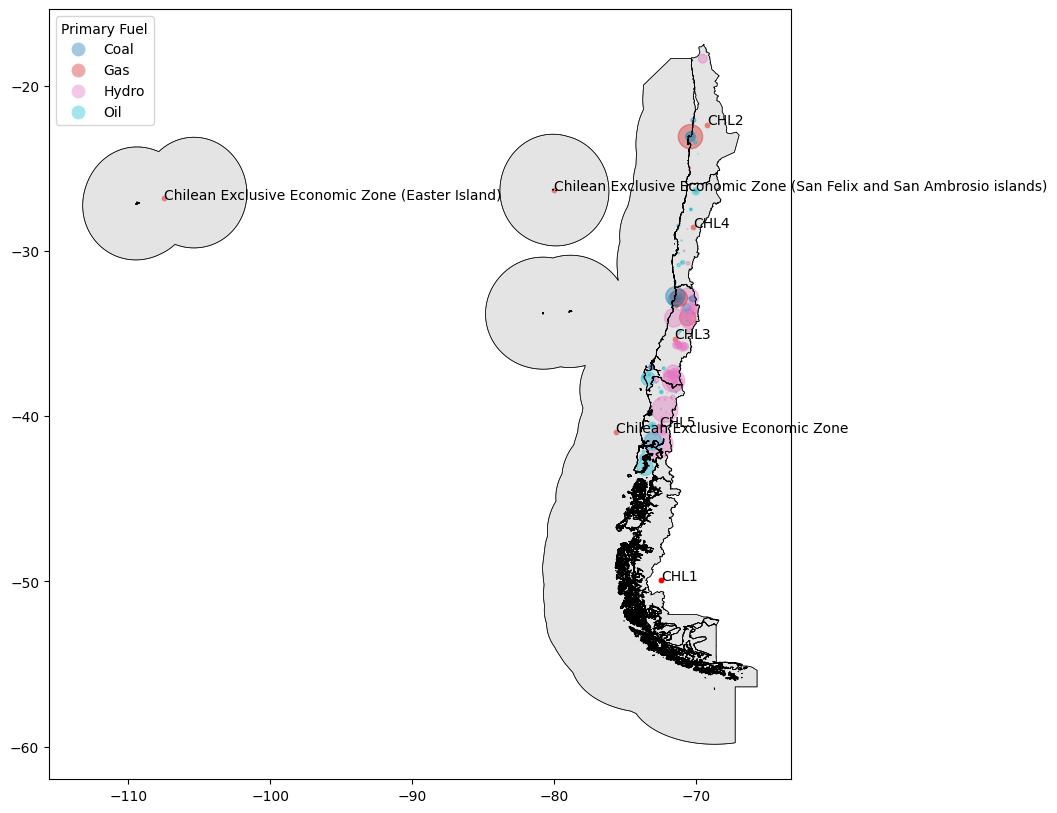

In [231]:
# Convert buses to a GeoDataFrame after the loop
gdf_buses = gpd.GeoDataFrame(n.buses, geometry=gpd.points_from_xy(n.buses.x, n.buses.y))
# Create a figure and axis object
fig, ax = plt.subplots(figsize=(10, 10))

# Plotting
gdf_buses.plot(ax=ax,marker="o", color="red", markersize=10)


# Plot the boundaries of the aggregated regions with a specified line width
aggregated_regions.boundary.plot(ax=ax, color="black", linewidth=0.5)

# Plot the base layer (Chile regions) without specifying the column to use the default geometry
aggregated_regions.plot(ax=ax, color="lightgrey",alpha=0.6)

# Plot the boundaries of the aggregated regions with a specified line width
aggregated_regions.boundary.plot(ax=ax, color="black", linewidth=0.5,alpha=0.6)

# Ensure pwp_chile GeoDataFrame is in the same CRS as aggregated_regions
pwp_chile = pwp_chile.to_crs(aggregated_regions.crs)

for idx, row in aggregated_centroids.iterrows():
    # Get the centroid of each region
    centroid = row["geometry"]
    # Annotate the plot with the region's NAME_1 at its centroid
    ax.text(centroid.x, centroid.y, row['NAME_1'], fontsize=10, ha='left')

# Plot pwp_chile with size based on estimated generation and color based on primary fuel
pwp_chile[pwp_chile["estimated_generation_gwh_2017"]>0].plot(
    ax=ax,
    column="primary_fuel",
    markersize=pwp_chile['estimated_generation_gwh_2017']/10,  # Adjust as necessary
    legend=True,
    legend_kwds={'title': 'Primary Fuel', 'loc': 'upper left'},
    alpha=0.4
    # Add a legend for primary_fuel categories
    # Color map for primary_fuel categories, adjust as needed
)



plt.show()


### Adding Generators

In [317]:
aggregated_cfDict = aggregated_cf.to_dict(orient='index')
aggregated_capacityDict = aggregated_capacity.to_dict(orient="index")

In [318]:
# add generators to model
for region in aggregated_cfDict.keys():
    for tech,value in aggregated_capacityDict[region].items():
        if value != 0:
            n.add("Generator",
                    f"{region} {tech}",
                    bus=region,
                    carrier=tech.lower(),
                    efficiency=aggregated_cfDict[region][tech],
                    p_nom=aggregated_capacityDict[region][tech],  
                    capital_cost=0,
                    #p_max_pu=1 if tech.lower() != 'hydro' else hydro_capacity_factor,  
                    p_nom_extendable=False
                    )

### Preparing Distances for Transmission Lines

In [319]:
regions = aggregated_regions[['geometry']]
index_values = regions.index[1]

In [320]:
points = regions.representative_point() # Finding representative points

In [321]:
points = regions.representative_point() # Finding representative points
points = points.to_crs(c)
distances = pd.concat({k: points.distance(p) for k, p in points.items()}, axis=1).div(1e3)

dict = {1: 'Region 1',
        2: 'Region 2',
        3: 'Region 3',
        4: 'Region 4',
        5: 'Region 5',}

distances.rename(columns=dict, inplace=True)
distances.rename(index=dict, inplace=True)
distances.reset_index(inplace=True)
distances.rename(columns={'NAME_1': 'aggRegion'}, inplace=True)
distances = distances.melt(id_vars='aggRegion', var_name='destination', value_name='distance')
distances = distances.drop_duplicates(subset=['distance'], keep='first')

C:\Users\alex-\AppData\Local\Temp\ipykernel_62292\3981691389.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distances = pd.concat({k: points.distance(p) for k, p in points.items()}, axis=1).div(1e3)


In [322]:
# Creating the nested dictionary
nested_dict = {}
for index, row in distances.iterrows():
    region = row['aggRegion']
    destination = row['destination']
    distance = row['distance']
    
    if region not in nested_dict:
        nested_dict[region] = {}
    
    nested_dict[region][destination] = distance

print(nested_dict)

{'CHL1': {'CHL1': 0.0}, 'CHL2': {'CHL1': 0.027333089903135446}, 'CHL3': {'CHL1': 0.013651130496543935, 'CHL2': 0.01368531065430497}, 'CHL4': {'CHL1': 0.02019262440821909, 'CHL2': 0.007149386582195649, 'CHL3': 0.00654149876927174}, 'CHL5': {'CHL1': 0.007961293810502309, 'CHL2': 0.019418227523065816, 'CHL3': 0.005743750373942405, 'CHL4': 0.012269022633014987}, 'Chilean Exclusive Economic Zone': {'CHL1': 0.009924648394700626, 'CHL2': 0.018532479759412152, 'CHL3': 0.005699617655548959, 'CHL4': 0.011533120648775609, 'CHL5': 0.0032846381327311263}, 'Chilean Exclusive Economic Zone (San Felix and San Ambrosio islands)': {'CHL1': 0.023384461731515937, 'CHL2': 0.011793404790949744, 'CHL3': 0.012336664473476993, 'CHL4': 0.009765430846577413, 'CHL5': 0.016146989413157415, 'Chilean Exclusive Economic Zone': 0.013485699526926015}, 'Chilean Exclusive Economic Zone (Easter Island)': {'CHL1': 0.040434439471887254, 'CHL2': 0.038639546737683494, 'CHL3': 0.0368984281963532, 'CHL4': 0.03692238090903729, '

### Adding Links

In [323]:
for start in nested_dict.keys():Cost
    for destination,distance in nested_dict[region].items():
        if distance!=0:
            n.add(
                "Link",
                f"{start}-{destination}",
                bus0=f"{start}",
                bus1=f"{destination}",
                efficiency=1,
                marginal_cost=0,
                p_min_pu=-1,
                length=distance* 1.5,
                capital_cost=400 * distance * 1.5,
                p_nom_extendable=True,
                carrier="HVAC",
        )

In [324]:
n.links.head()

attribute,bus0,bus1,type,carrier,efficiency,build_year,lifetime,p_nom,p_nom_mod,p_nom_extendable,...,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt
Link,,,,,,,,,,,,,,,,,,,,,
CHL1-CHL1,CHL1,CHL1,,HVAC,1.0,0,inf,0.0,0.0,True,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
CHL1-CHL2,CHL1,CHL2,,HVAC,1.0,0,inf,0.0,0.0,True,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
CHL1-CHL3,CHL1,CHL3,,HVAC,1.0,0,inf,0.0,0.0,True,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
CHL1-CHL4,CHL1,CHL4,,HVAC,1.0,0,inf,0.0,0.0,True,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
CHL1-CHL5,CHL1,CHL5,,HVAC,1.0,0,inf,0.0,0.0,True,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0


### Adding Population and Regional Demand

In [325]:
population = {
    "Antofagasta": 641, "Araucanía": 1002, "Arica y Parinacota": 247,
    "Atacama": 321, "Aysén del General Ibañez del Cam": 110, "Bío-Bío": 2141,
    "Coquimbo": 794, "Libertador General Bernardo O'Hi": 935, "Los Lagos": 845,
    "Los Ríos": 410, "Magallanes y Antártica Chilena": 166, "Maule": 1058, "Santiago Metropolitan": 7483,
    "Tarapacá": 353, "Valparaíso": 1860, "Nuble": 480, "Los Ríos": 384
    }

population = pd.DataFrame.from_dict(population, orient="index", columns=["regional_population"])
population["percentage"] = population["regional_population"] / population["regional_population"].sum() * 100
population.reset_index(inplace=True)
population.rename(columns={'index': 'NAME_1'}, inplace=True)
population.rename(columns={'NAME_1': 'Regions'}, inplace=True)
population = regions_converter.merge(population, on="Regions",how="right")
population = population.groupby("aggRegions").agg({"percentage": "sum", "regional_population": "sum"})
population["percentage"] = population["percentage"].round()
print(population)

            percentage  regional_population
aggRegions                                 
CHL1               1.0                  276
CHL2               7.0                 1241
CHL3              72.0                13477
CHL4               6.0                 1115
CHL5              12.0                 2231


#### Load load Data

In [326]:
fn="./data/load.csv"
ts = pd.read_csv(fn,index_col="time")
ts.index = pd.to_datetime(ts.index)
ts = ts["CL"]
ts = ts.to_frame()
tsindex = ts.index

for i in range(len(population)):
      ts[population.index[i]] = ts["CL"].values * population.iloc[i,0]/100

ts = ts.drop(columns='CL')
ts.head()

,CHL1,CHL2,CHL3,CHL4,CHL5
time,,,,,
2013-01-01 00:00:00,122.735366,859.147564,8836.946373,736.412198,1472.824396
2013-01-01 01:00:00,120.546241,843.823687,8679.329354,723.277446,1446.554892
2013-01-01 02:00:00,115.711293,809.979050,8331.213090,694.267757,1388.535515
2013-01-01 03:00:00,107.151549,750.060844,7714.911538,642.909295,1285.818590
2013-01-01 04:00:00,98.873782,692.116471,7118.912270,593.242689,1186.485378


In [327]:
resolution = 3
ts = ts.resample(f"{resolution}h").mean()
tsDict = ts.to_dict(orient="index")

In [328]:
n.set_snapshots(ts.index)
n.snapshot_weightings.loc[:,:] = resolution
n.snapshot_weightings.head(3)


,objective,stores,generators
snapshot,,,
2013-01-01 00:00:00,3.0,3.0,3.0
2013-01-01 03:00:00,3.0,3.0,3.0
2013-01-01 06:00:00,3.0,3.0,3.0


In [329]:
for timestamp in tsDict.keys():
    for region,load in tsDict[timestamp].items():
        n.add(
            "Load",
            f"Demand {region} {timestamp}",
            bus=f"{region}",
            p_set=load
        )
z=1

### Add Renewable Generation

In [212]:
# Define the regex pattern to match variations of "offshore wind"
technology_index = costs.index
pattern = re.compile(r'[A-Za-z]*wind$', re.IGNORECASE)

# Search for rows matching the regex pattern
matching_rows = [row for row in technology_index if re.search(pattern, row)]

# Print the matching rows
for row in matching_rows:
    print(row)

offwind
onwind


#### Adding Offshore

In [340]:

### Import
fn="./data/A_Offshore.csv"
tsOffshore = pd.read_csv(fn)
tsOffshore.index = tsindex
tsOffshore = tsOffshore.resample(f"{resolution}h").first()

In [331]:
region = "Chilean Exclusive Economic Zone"
n.add("Generator",
    f"{region} OffWind",
    bus=region,
    carrier="offwind",
    p_max_pu=tsOffshore[region],
    marginal_cost=costs.at["offwind", "VOM"],
    capital_cost=costs.at["offwind", "capital_cost"],
    efficiency=costs.at["offwind", "efficiency"]
)
           

In [332]:
region = "Chilean Exclusive Economic Zone (San Felix and San Ambrosio islands)"
n.add("Generator",
    f"{region} OffWind",
    bus=region,
    carrier="offwind",
    p_max_pu=tsOffshore[region],
    marginal_cost=costs.at["offwind", "VOM"],
    capital_cost=costs.at["offwind", "capital_cost"],
    efficiency=costs.at["offwind", "efficiency"]
)

#### Adding Onshore Wind

In [339]:
### Import
fn="./data/A_Wind.csv"
tsOnshore = pd.read_csv(fn)
tsOnshore.index = tsindex
tsOnshore = tsOnshore.resample(f"{resolution}h").first()


In [334]:
for region, data in tsOnshore.items():
        n.add(
            "Generator",
            f"{region} OnWind",
            bus=region,
            carrier="onwind",
            p_max_pu=tsOnshore[region],
            marginal_cost=costs.at["onwind", "VOM"],
            capital_cost=costs.at["onwind", "capital_cost"],
            efficiency=costs.at["onwind", "efficiency"],
            p_nom_extendable=True,
        )

#### Adding Solar Power

In [336]:
fn="./data/A_Solar.csv"
tsSolar = pd.read_csv(fn)
tsSolar.index = tsindex
tsSolar = tsSolar.resample(f"{resolution}h").first()


In [338]:
# Adding Solar Power
for region, data in tsSolar.items():
        n.add(
            "Generator",
            f"{region} Solar",
            bus=region,
            carrier="solar",
            p_max_pu=tsSolar[region],
            marginal_cost=costs.at["solar", "VOM"],
            capital_cost=costs.at["solar", "capital_cost"],
            efficiency=costs.at["solar", "efficiency"],
            p_nom_extendable=True,
        )

#### Check

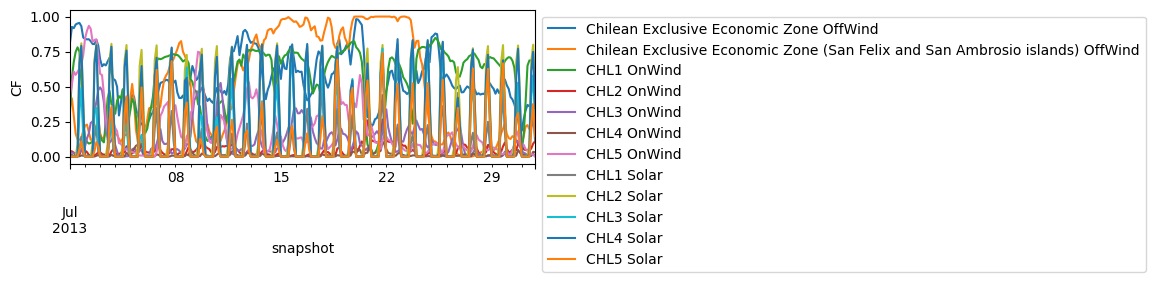

In [349]:
# Assuming n.generators_t.p_max_pu.loc["2013-12"] is your data series
# Plotting the data
ax = n.generators_t.p_max_pu.loc["2013-07"].plot(figsize=(6, 2), ylabel="CF")

# Getting the legend from the plot
legend = ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Showing the plot
plt.show()

### Adding Demand

## Investigation 